Integrantes:
Jesús Márquez,
Mariana Ramírez

Sección: MINERIA DE DATOS_003D

## Introducción al Análisis de Películas

Este notebook tiene como objetivo principal la preparación y análisis inicial de un conjunto de películas.


El proceso comienza con la carga de los datos desde un archivo CSV y una exploración detallada para comprender su estructura, tipos de datos y la presencia de valores nulos.

Inicio del código

Acá importamos las librerías Pandas y numpy, que serviran para manipular/analizar datos de los dataframe y para las operaciones numéricas y manejo de arrays respectivamente. Además de configurar pandas para que pueda mostrar hasta 500 filas al imprimir o querer visualizar los datos.

In [ ]:
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', 500) #capability

Importamos seaborn y matplotlib.pyplot.
Seaborn es utilizado para crear gráficos mas fáciles de interpretar y matplotlib.pyplot también es para generar gráficos en python.

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

Código para cargar el dataset desde los archivos, y lo deja preparado para ser utilizado y analizado.

In [ ]:
df = pd.read_csv("/content/movies.csv")

Código para visualizar las primeras 5 filas y todas las columnas, meramente para ver si se cargo correctamente el dataset.

In [ ]:
df.head()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
0,0,237000000,Action Adventure Fantasy Science Fiction,http://www.avatarmovie.com/,19995,culture clash future space war space colony so...,en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,...,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800,Sam Worthington Zoe Saldana Sigourney Weaver S...,"[{'name': 'Stephen E. Rivkin', 'gender': 0, 'd...",James Cameron
1,1,300000000,Adventure Fantasy Action,http://disney.go.com/disneypictures/pirates/,285,ocean drug abuse exotic island east india trad...,en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,...,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500,Johnny Depp Orlando Bloom Keira Knightley Stel...,"[{'name': 'Dariusz Wolski', 'gender': 2, 'depa...",Gore Verbinski
2,2,245000000,Action Adventure Crime,http://www.sonypictures.com/movies/spectre/,206647,spy based on novel secret agent sequel mi6,en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,...,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466,Daniel Craig Christoph Waltz L\u00e9a Seydoux ...,"[{'name': 'Thomas Newman', 'gender': 2, 'depar...",Sam Mendes
3,3,250000000,Action Crime Drama Thriller,http://www.thedarkknightrises.com/,49026,dc comics crime fighter terrorist secret ident...,en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,...,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106,Christian Bale Michael Caine Gary Oldman Anne ...,"[{'name': 'Hans Zimmer', 'gender': 2, 'departm...",Christopher Nolan
4,4,260000000,Action Adventure Science Fiction,http://movies.disney.com/john-carter,49529,based on novel mars medallion space travel pri...,en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,...,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124,Taylor Kitsch Lynn Collins Samantha Morton Wil...,"[{'name': 'Andrew Stanton', 'gender': 2, 'depa...",Andrew Stanton


Código para visualizar las ultimas 5 filas del dataset.

In [ ]:
df.tail()

,index,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,...,runtime,spoken_languages,status,tagline,title,vote_average,vote_count,cast,crew,director
4798,4798,220000,Action Crime Thriller,NaN,9367,united states\u2013mexico barrier legs arms pa...,es,El Mariachi,El Mariachi just wants to play his guitar and ...,14.269792,...,81.0,"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",Released,"He didn't come looking for trouble, but troubl...",El Mariachi,6.6,238,Carlos Gallardo Jaime de Hoyos Peter Marquardt...,"[{'name': 'Robert Rodriguez', 'gender': 0, 'de...",Robert Rodriguez
4799,4799,9000,Comedy Romance,NaN,72766,NaN,en,Newlyweds,A newlywed couple's honeymoon is upended by th...,0.642552,...,85.0,[],Released,A newlywed couple's honeymoon is upended by th...,Newlyweds,5.9,5,Edward Burns Kerry Bish\u00e9 Marsha Dietlein ...,"[{'name': 'Edward Burns', 'gender': 2, 'depart...",Edward Burns
4800,4800,0,Comedy Drama Romance TV Movie,http://www.hallmarkchannel.com/signedsealeddel...,231617,date love at first sight narration investigati...,en,"Signed, Sealed, Delivered","""Signed, Sealed, Delivered"" introduces a dedic...",1.444476,...,120.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,"Signed, Sealed, Delivered",7.0,6,Eric Mabius Kristin Booth Crystal Lowe Geoff G...,"[{'name': 'Carla Hetland', 'gender': 0, 'depar...",Scott Smith
4801,4801,0,NaN,http://shanghaicalling.com/,126186,NaN,en,Shanghai Calling,When ambitious New York attorney Sam is sent t...,0.857008,...,98.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,A New Yorker in Shanghai,Shanghai Calling,5.7,7,Daniel Henney Eliza Coupe Bill Paxton Alan Ruc...,"[{'name': 'Daniel Hsia', 'gender': 2, 'departm...",Daniel Hsia
4802,4802,0,Documentary,NaN,25975,obsession camcorder crush dream girl,en,My Date with Drew,Ever since the second grade when he first saw ...,1.929883,...,90.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,NaN,My Date with Drew,6.3,16,Drew Barrymore Brian Herzlinger Corey Feldman ...,"[{'name': 'Clark Peterson', 'gender': 2, 'depa...",Brian Herzlinger


Devuelve los nombres de las columnas del dataframe

In [ ]:
df.columns

Index(['index', 'budget', 'genres', 'homepage', 'id', 'keywords',
       'original_language', 'original_title', 'overview', 'popularity',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'vote_average', 'vote_count', 'cast', 'crew', 'director'],
      dtype='object')

Para visualizar el total de filas y columnas.

In [ ]:
df.shape

(4803, 24)

Sirve para para obtener cuantas columnas son int/numéricas dentro del dataset.

In [ ]:
df.describe().count() #solo a las columnas numericas

,0
index,8
budget,8
id,8
popularity,8
revenue,8
runtime,8
vote_average,8
vote_count,8


Muestra estructura del Dataframe y detectando los datos faltantes.

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   index                 4803 non-null   int64  
 1   budget                4803 non-null   int64  
 2   genres                4775 non-null   object 
 3   homepage              1712 non-null   object 
 4   id                    4803 non-null   int64  
 5   keywords              4391 non-null   object 
 6   original_language     4803 non-null   object 
 7   original_title        4803 non-null   object 
 8   overview              4800 non-null   object 
 9   popularity            4803 non-null   float64
 10  production_companies  4803 non-null   object 
 11  production_countries  4803 non-null   object 
 12  release_date          4802 non-null   object 
 13  revenue               4803 non-null   int64  
 14  runtime               4801 non-null   float64
 15  spoken_languages     

**La siguiente parte indicará en diferentes columnas(todas categoricas) si algún resultado se repite y cuantas veces. Estos también nos ayuda a ver y elegir cual dejar y cual eliminar para una mejor comprensión del dataset.**

In [ ]:
df['genres'].value_counts()

,count
genres,
Drama,370
Comedy,282
Drama Romance,164
Comedy Romance,144
Comedy Drama,142
...,...
Drama Fantasy Horror Mystery Romance,1
Fantasy Family Action,1
Thriller Crime Romance,1


In [ ]:
df['homepage'].value_counts()

,count
homepage,
http://www.missionimpossible.com/,4
http://www.thehungergames.movie/,4
http://www.kungfupanda.com/,3
http://www.transformersmovie.com/,3
http://www.thehobbit.com/,3
...,...
http://www.julieandjulia.com/,1
http://www.backtothefuture.com/movies/backtothefuture3,1
http://www.hesjustnotthatintoyoumovie.com/,1


In [ ]:
df['keywords'].value_counts()

,count
keywords,
independent film,55
woman director,42
duringcreditsstinger,15
sport,13
independent film woman director,10
...,...
sheriff horse outlaw jesse james cole younger,1
sex adultery based on novel fishing isolation,1
music record rock and roll pop hip-hop fab four,1


In [ ]:
df['original_language'].value_counts()

,count
original_language,
en,4505
fr,70
es,32
zh,27
de,27
hi,19
ja,16
it,14
cn,12


In [ ]:
df['original_title'].value_counts()

,count
original_title,
Batman,2
Out of the Blue,2
Polisse,1
The I Inside,1
"Ultramarines: A Warhammer 40,000 Movie",1
...,...
Drag Me to Hell,1
Southpaw,1
Sicario,1


In [ ]:
df['overview'].value_counts()

,count
overview,
"'Breaking Upwards' explores a young, real-life New York couple who, four years in and battling codependency, decide to intricately strategize their own break up. Based on an actual experiment devised by director/actor Daryl Wein and actress Zoe Lister-Jones, the film loosely interprets a year in their lives exploring alternatives to monogamy, and the madness that ensues. An uncensored look at young love, lust, and the pangs of codependency, 'Breaking Upwards' follows its characters as they navigate each others' emotions across the city they love. It begs the question: is it ever possible to grow apart together?",1
Created by the members of a Nairobi-based arts collective — who have removed their names from the film for fear of reprisal — this anthology film that dramatizes true-life stories from Kenya’s oppressed LGBTQ community is both a labour of love and a bold act of militancy.,1
"Josh's life is pretty much in the toilet. He's a failed NYC indie rocker, and a failing booking agent. But he finds the potential of a small victory in a really bad idea. He decides to purchase a 1985 Lazy Boy on eBay, just like the one his dad had when Josh was a kid. He'll drive cross-country for the chair, staying with Emily at his brother's house on the way, and deliver it to his father as a surprise birthday gift. But when Rhett ends up coming along for the ride, it's three people and a giant purple puffy chair in a too-small van... and one of them has to go before the trip's end.",1
"During an all-night, drug-fueled party at an abandoned asylum known for the horrific treatment of its patients, a group of ordinary teens decide to experiment with the occult, mysteriously leading to a violent possession. In an effort to find help, the group rushes to escape, only to find themselves locked inside with no means of communication. Tempers flare, trusts are broken and in attempt to save one of their friends possessed by the demon, the amateurs try to perform an exorcism. Instead of solving the problem, and unbeknownst to them, they unleash an even more powerful and vengeful spirit, one with a distinct motive and which wants them all dead. The teen's only chance of survival is to uncover the asylum's deep mysteries and find a way out before it's too late.",1
"Jay Austin wants to sell you a used car, but watch out! Many victims have fallen prey to his smiling face and hasty promises. Austin does everything his way until his dishonesty and manipulation are exposed. Like many men, he becomes disgusted by the masks he wears and the lies he tells. In every man's life, there can be a turning point. When Jay makes his turn, he never looks back.",1
...,...
"John Carter is a war-weary, former military captain who's inexplicably transported to the mysterious and exotic planet of Barsoom (Mars) and reluctantly becomes embroiled in an epic conflict. It's a world on the brink of collapse, and Carter rediscovers his humanity when he realizes the survival of Barsoom and its people rests in his hands.",1
"Following the death of District Attorney Harvey Dent, Batman assumes responsibility for Dent's crimes to protect the late attorney's reputation and is subsequently hunted by the Gotham City Police Department. Eight years later, Batman encounters the mysterious Selina Kyle and the villainous Bane, a new terrorist leader who overwhelms Gotham's finest. The Dark Knight resurfaces to protect a city that has branded him an enemy.",1
"A cryptic message from Bond’s past sends him on a trail to uncover a sinister organization. While M battles political forces to keep the secret service alive, Bond peels back the layers of deceit to reveal the terrible truth behind SPECTRE.",1


In [ ]:
df['production_companies'].value_counts()

,count
production_companies,
[],351
"[{""name"": ""Paramount Pictures"", ""id"": 4}]",58
"[{""name"": ""Universal Pictures"", ""id"": 33}]",45
"[{""name"": ""New Line Cinema"", ""id"": 12}]",38
"[{""name"": ""Columbia Pictures"", ""id"": 5}]",37
...,...
"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""name"": ""BrownHouse Productions"", ""id"": 26423}, {""name"": ""Bottom of the Ninth Productions"", ""id"": 65559}]",1
"[{""name"": ""Scott Rudin Productions"", ""id"": 258}]",1
"[{""name"": ""New Line Cinema"", ""id"": 12}, {""name"": ""Juno Pix"", ""id"": 4286}, {""name"": ""Cecchi Gori Pictures"", ""id"": 65394}]",1


In [ ]:
df['production_countries'].value_counts()

,count
production_countries,
"[{""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",2977
"[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}, {""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",181
[],174
"[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""}]",131
"[{""iso_3166_1"": ""DE"", ""name"": ""Germany""}, {""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",119
"[{""iso_3166_1"": ""CA"", ""name"": ""Canada""}, {""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",88
"[{""iso_3166_1"": ""FR"", ""name"": ""France""}]",49
"[{""iso_3166_1"": ""CA"", ""name"": ""Canada""}]",46
"[{""iso_3166_1"": ""AU"", ""name"": ""Australia""}, {""iso_3166_1"": ""US"", ""name"": ""United States of America""}]",46


In [ ]:
df['release_date'].value_counts()

,count
release_date,
2006-01-01,10
2002-01-01,8
2014-12-25,7
2004-09-03,7
2013-07-18,7
...,...
2013-04-20,1
2014-03-15,1
2013-06-28,1


In [ ]:
df['spoken_languages'].value_counts()

,count
spoken_languages,
"[{""iso_639_1"": ""en"", ""name"": ""English""}]",3171
"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}]",127
"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}]",114
[],86
"[{""iso_639_1"": ""es"", ""name"": ""Espa\u00f1ol""}, {""iso_639_1"": ""en"", ""name"": ""English""}]",54
...,...
"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}, {""iso_639_1"": ""de"", ""name"": ""Deutsch""}, {""iso_639_1"": ""sv"", ""name"": ""svenska""}, {""iso_639_1"": ""it"", ""name"": ""Italiano""}, {""iso_639_1"": ""ru"", ""name"": ""P\u0443\u0441\u0441\u043a\u0438\u0439""}]",1
"[{""iso_639_1"": ""is"", ""name"": ""\u00cdslenska""}, {""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""ru"", ""name"": ""P\u0443\u0441\u0441\u043a\u0438\u0439""}, {""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""}]",1
"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso_639_1"": ""tr"", ""name"": ""T\u00fcrk\u00e7e""}, {""iso_639_1"": ""el"", ""name"": ""\u03b5\u03bb\u03bb\u03b7\u03bd\u03b9\u03ba\u03ac""}, {""iso_639_1"": ""zh"", ""name"": ""\u666e\u901a\u8bdd""}]",1


In [ ]:
df['status'].value_counts()

,count
status,
Released,4795
Rumored,5
Post Production,3


In [ ]:
df['tagline'].value_counts()

,count
tagline,
Based on a true story.,3
There are two sides to every love story.,2
From zero to hero.,2
Be careful what you wish for.,2
What could go wrong?,2
...,...
Every war has a beginning.,1
First came love... then came Reverend Frank.,1
Get off the bench and get into the game.,1


In [ ]:
df['title'].value_counts()

,count
title,
The Host,2
Batman,2
Out of the Blue,2
Awake,1
Beneath Hill 60,1
...,...
Drag Me to Hell,1
Southpaw,1
Sicario,1


In [ ]:
df['cast'].value_counts()

,count
cast,
William Shatner Leonard Nimoy DeForest Kelley James Doohan George Takei,6
Patrick Stewart Jonathan Frakes Brent Spiner LeVar Burton Michael Dorn,4
Jennifer Lawrence Josh Hutcherson Liam Hemsworth Woody Harrelson Elizabeth Banks,3
Zac Efron Vanessa Hudgens Ashley Tisdale Lucas Grabeel Corbin Bleu,3
Eddie Murphy Judge Reinhold John Ashton Ronny Cox Paul Reiser,2
...,...
Johnny Depp Helena Bonham Carter Emily Watson Tracey Ullman Paul Whitehouse,1
Sean Hayes Will Sasso Chris Diamantopoulos Jane Lynch Sof\u00eda Vergara,1
Michael Douglas Andy Garc\u00eda Kate Capshaw Shigeru K\u00f4yama John Spencer,1


In [ ]:
df['crew'].value_counts()

crew
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [ ]:
df['director'].value_counts()

,count
director,
Steven Spielberg,27
Woody Allen,21
Clint Eastwood,20
Martin Scorsese,20
Spike Lee,16
...,...
Bradley Rust Gray,1
Collin Joseph Neal,1
Kirk Loudon,1


**Posteriormente, se realiza una fase de limpieza de datos, donde se eliminan las filas con valores nulos para asegurar la integridad del conjunto de datos.**

**Empezando con la verificación de cuantos nulls hay dentro de cada columna, que también nos ayudara a identificar cual columna nos sirve o no.**

In [ ]:
df.isnull().sum()

,0
index,0
budget,0
genres,28
homepage,3091
id,0
keywords,412
original_language,0
original_title,0
overview,3
popularity,0


Eliminando las columnas que nos parecen innecesarias e irelevantes para el analisis del dataset

In [ ]:
df.drop(columns=['homepage','keywords','overview','production_companies','production_countries','release_date','spoken_languages','status','original_title','crew','cast','director','genres','original_language'], inplace=True, errors='ignore')

Verificando si se eliminaron las columnas correctamente.

In [ ]:
df.columns

Index(['index', 'budget', 'id', 'popularity', 'revenue', 'runtime', 'tagline',
       'title', 'vote_average', 'vote_count'],
      dtype='object')

In [ ]:
df.shape

(4803, 10)

In [ ]:
df_limpio = df.dropna()

Verificando la cantidad de filas que quedan después de borrar los nulls

In [ ]:
df_limpio.shape

(3959, 10)

Verificando si hay algún null después de limpiarlo

In [ ]:
df_limpio.isnull().sum()

,0
index,0
budget,0
id,0
popularity,0
revenue,0
runtime,0
tagline,0
title,0
vote_average,0
vote_count,0


Creando el csv del dataframe ya limpio de nulls y con las columnas que no utilizaremos ya eliminadas.

In [ ]:
df_limpio.to_csv("movie_limpio.csv")

 Las variables categóricas se transforman utilizando Binary Encoding para prepararlas para futuros modelos de aprendizaje automático, mientras que las columnas booleanas se convierten a formato numérico (0 y 1).

 Comenzamos con la instalaciones e imports necesarias para hacer el encoding.

In [ ]:
pip install category_encoders

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import category_encoders as ce

Convierte variables categoricas en valores numericos para después en modelos de machine learning usarlo.

In [ ]:
# Using the cleaned DataFrame `df_limpio` for encoding to avoid issues with missing values.
# 3. Binary Encoding usando Category Encoders
# Este encoder es ideal para columnas con alta cardinalidad como las comunas
be = ce.BinaryEncoder(cols=['tagline','title'])
df_binary = be.fit_transform(df_limpio[['tagline','title']])

Concatena los datos originales con las versiones enconding, dejando el dataset completamente listo para usar en machine learning

In [ ]:
#codigo para concatenar
df_final = pd.concat([df_limpio.drop(columns=['tagline','title']), df_binary], axis=1)


Muestra los datos faltantes de cada variable, para verificar si el encoding fue realizado correctamente.

In [ ]:
df_final.isnull().sum()

,0
index,0
budget,0
id,0
popularity,0
revenue,0
runtime,0
vote_average,0
vote_count,0
tagline_0,0
tagline_1,0


Visualizar las primeros 5 filas

In [ ]:
df_final.head()

,index,budget,id,popularity,revenue,runtime,vote_average,vote_count,tagline_0,tagline_1,...,title_2,title_3,title_4,title_5,title_6,title_7,title_8,title_9,title_10,title_11
0,0,237000000,19995,150.437577,2787965087,162.0,7.2,11800,0,0,...,0,0,0,0,0,0,0,0,0,1
1,1,300000000,285,139.082615,961000000,169.0,6.9,4500,0,0,...,0,0,0,0,0,0,0,0,1,0
2,2,245000000,206647,107.376788,880674609,148.0,6.3,4466,0,0,...,0,0,0,0,0,0,0,0,1,1
3,3,250000000,49026,112.312950,1084939099,165.0,7.6,9106,0,0,...,0,0,0,0,0,0,0,1,0,0
4,4,260000000,49529,43.926995,284139100,132.0,6.1,2124,0,0,...,0,0,0,0,0,0,0,1,0,1


Total de filas y columnas, después de limpiar nulls y el encoding.

In [ ]:
df_final.shape

(3959, 32)

Finalmente, se genera un mapa de calor de correlación para visualizar las relaciones entre las variables numéricas, proporcionando una base sólida para análisis más profundos y la construcción de modelos.

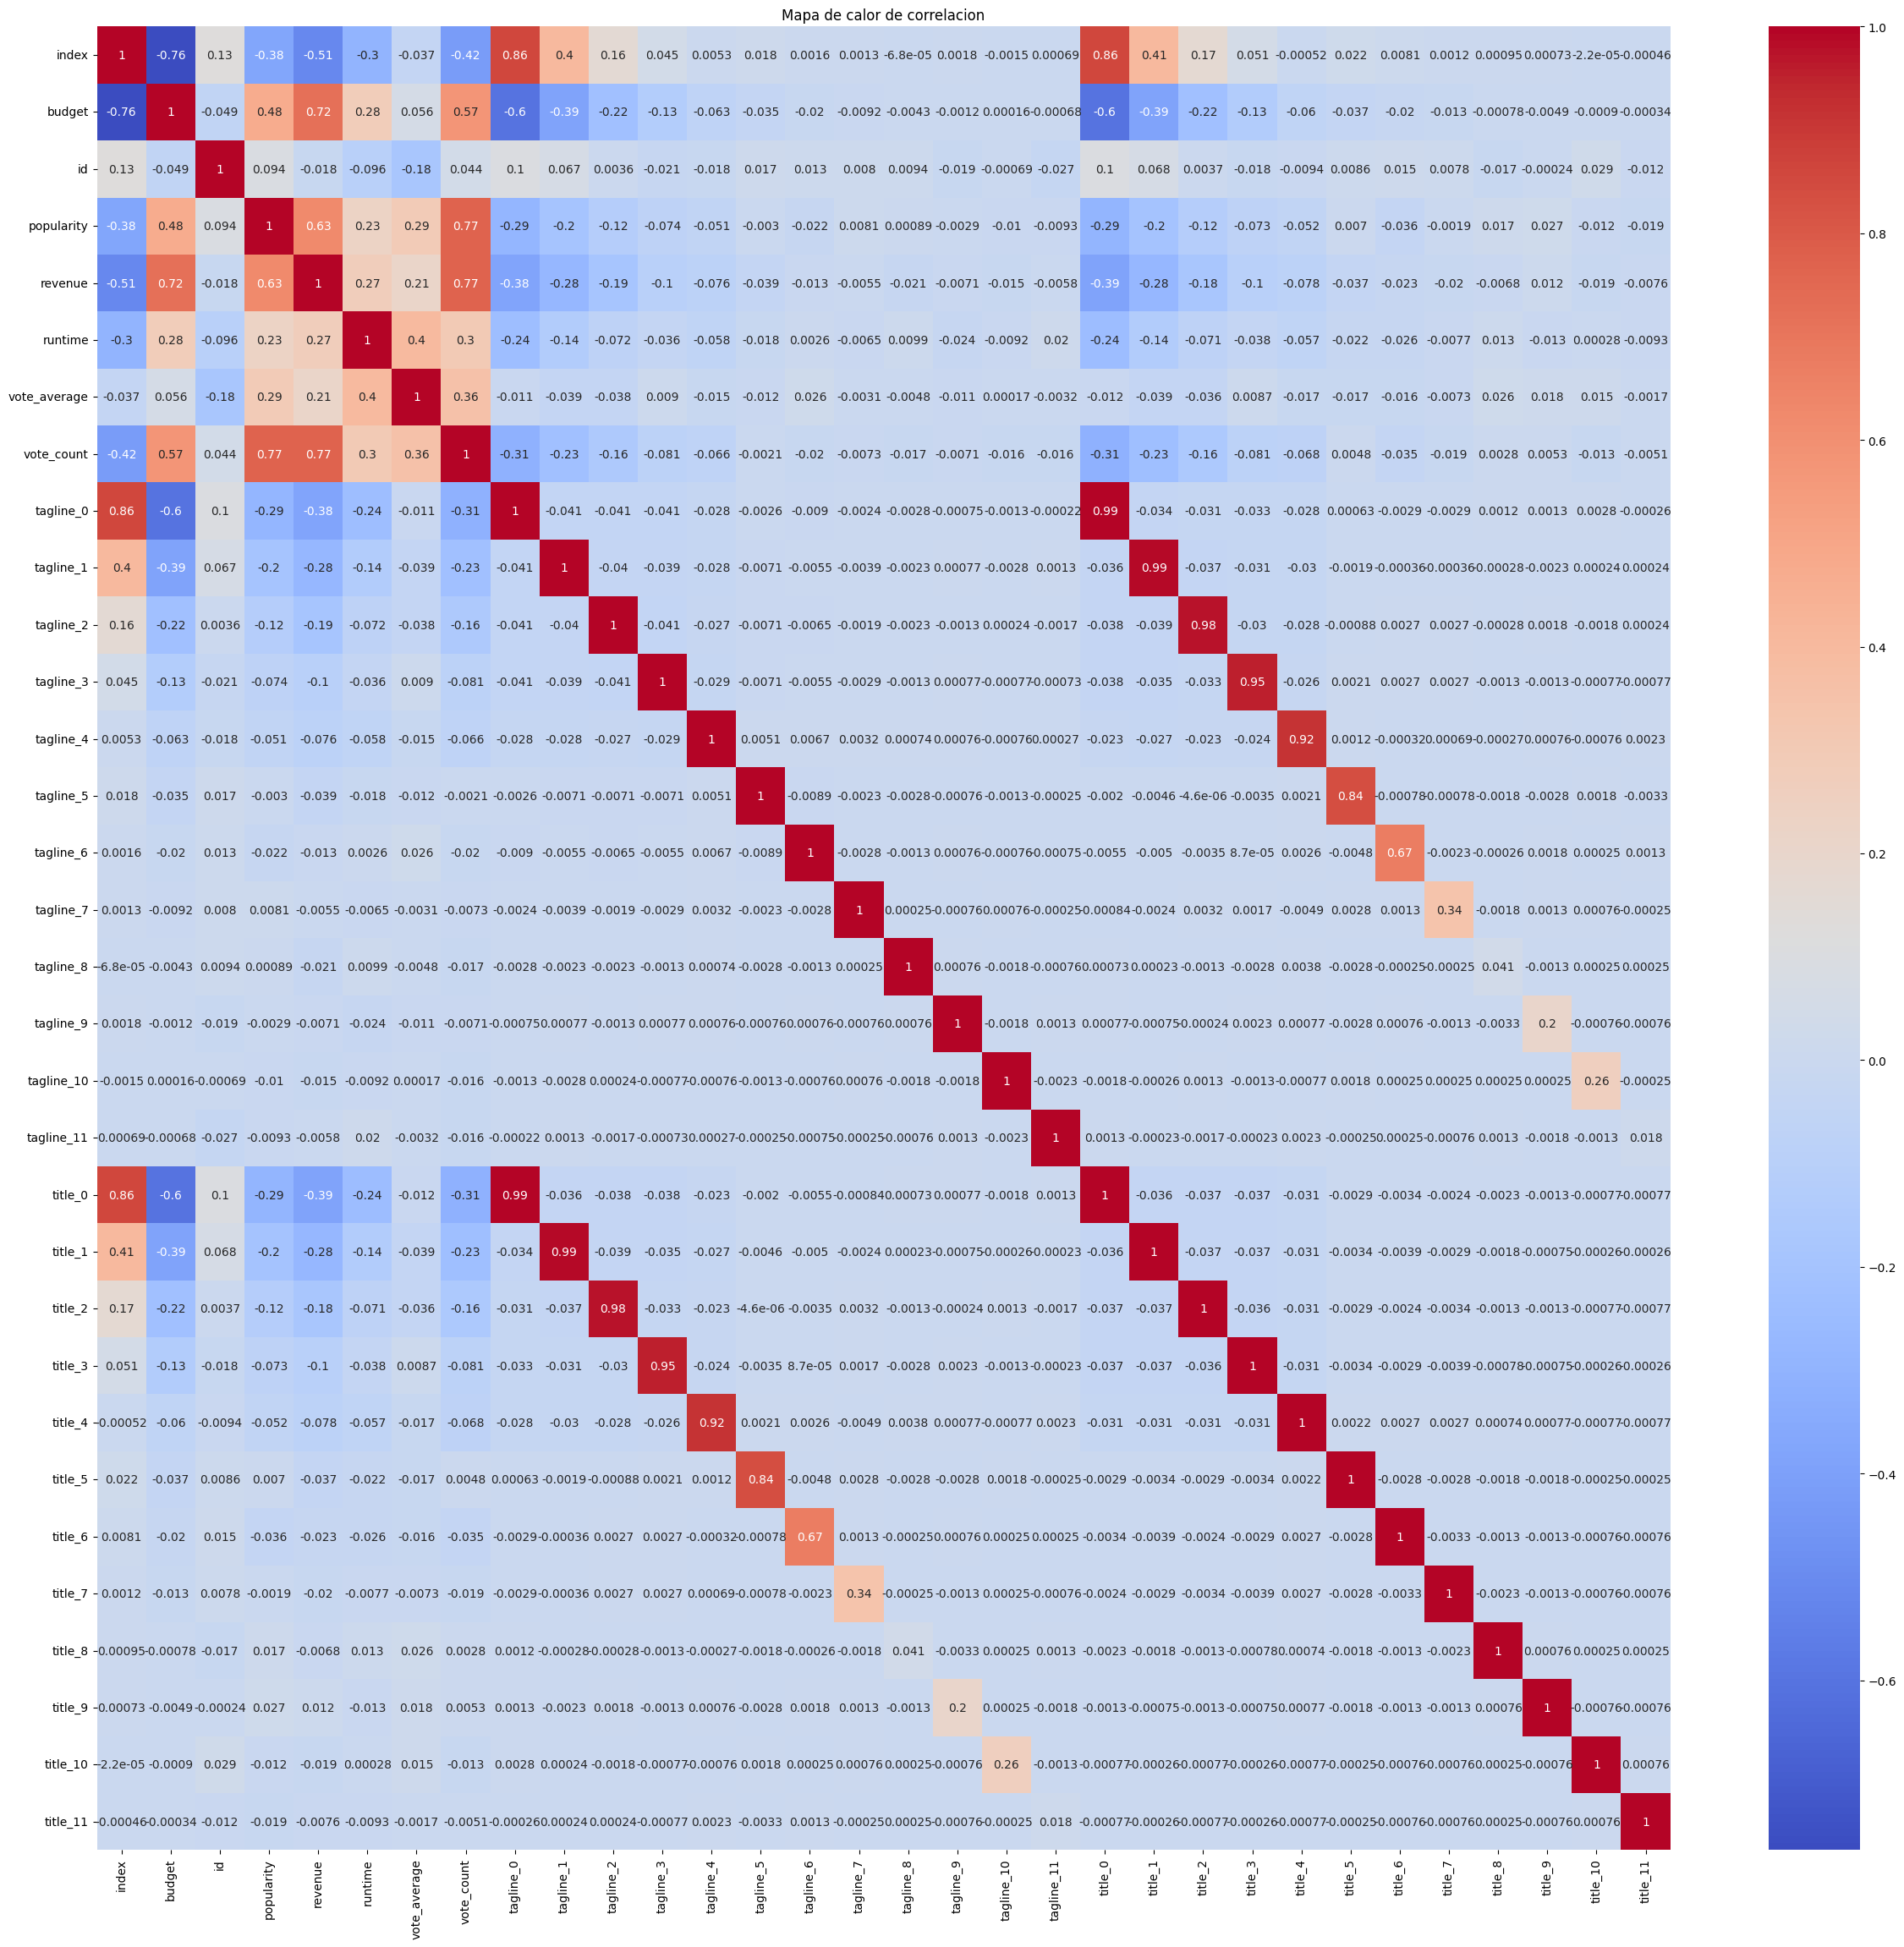

In [ ]:
corr = df_final.select_dtypes(include='number').corr() #correlacion

plt.figure(figsize=(30,28))

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Mapa de calor de correlacion")
plt.show()